In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

In [2]:
train_values = pd.read_csv(r"C:\Users\yusse\AppData\Local\Temp\9ea21ba6-fd04-488a-b948-91d73e44a987_archive.zip.987\train_values_wJZrCmI.csv")
train_values

,row_id,country,is_urban,age,female,married,religion,relationship_to_hh_head,education_level,literacy,...,reg_formal_nbfi_account,financially_included,active_bank_user,active_mm_user,active_formal_nbfi_user,active_informal_nbfi_user,nonreg_active_mm_user,num_formal_institutions_last_year,num_informal_institutions_last_year,num_financial_activities_last_year
0,0,C,False,18.0,True,True,P,Other,1.0,True,...,False,True,True,False,False,False,False,1,0,1
1,1,C,True,30.0,True,True,P,Other,1.0,True,...,False,True,True,False,False,False,False,1,0,0
2,2,A,False,20.0,True,True,Q,Spouse,1.0,True,...,False,False,False,False,False,False,False,0,0,0
3,3,A,False,61.0,False,True,Q,Head,0.0,False,...,False,False,False,False,False,False,False,0,0,0
4,4,D,False,26.0,True,True,X,Spouse,1.0,True,...,False,False,False,False,False,False,False,1,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12595,12595,C,True,50.0,False,True,P,Head,1.0,True,...,False,True,False,False,False,False,False,2,0,1
12596,12596,D,False,90.0,False,False,O,Head,0.0,True,...,False,False,False,False,False,False,False,0,0,0
12597,12597,J,False,52.0,True,False,X,Head,1.0,False,...,False,True,False,False,False,True,False,0,1,0
12598,12598,I,False,40.0,False,True,Q,Head,0.0,False,...,False,False,False,False,False,False,False,0,0,0


In [3]:
train_labels = pd.read_csv(r"C:\Users\yusse\AppData\Local\Temp\614d3654-185d-4f94-8928-4dd65b7f3878_archive.zip.878\train_labels.csv")
train_labels

,row_id,poverty_probability
0,0,0.515
1,1,0.981
2,2,0.982
3,3,0.879
4,4,0.796
...,...,...
12595,12595,0.990
12596,12596,0.950
12597,12597,0.342
12598,12598,0.846


In [4]:
train = train_values.merge(train_labels, on="row_id", how="left")

In [5]:
train

,row_id,country,is_urban,age,female,married,religion,relationship_to_hh_head,education_level,literacy,...,financially_included,active_bank_user,active_mm_user,active_formal_nbfi_user,active_informal_nbfi_user,nonreg_active_mm_user,num_formal_institutions_last_year,num_informal_institutions_last_year,num_financial_activities_last_year,poverty_probability
0,0,C,False,18.0,True,True,P,Other,1.0,True,...,True,True,False,False,False,False,1,0,1,0.515
1,1,C,True,30.0,True,True,P,Other,1.0,True,...,True,True,False,False,False,False,1,0,0,0.981
2,2,A,False,20.0,True,True,Q,Spouse,1.0,True,...,False,False,False,False,False,False,0,0,0,0.982
3,3,A,False,61.0,False,True,Q,Head,0.0,False,...,False,False,False,False,False,False,0,0,0,0.879
4,4,D,False,26.0,True,True,X,Spouse,1.0,True,...,False,False,False,False,False,False,1,0,3,0.796
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12595,12595,C,True,50.0,False,True,P,Head,1.0,True,...,True,False,False,False,False,False,2,0,1,0.990
12596,12596,D,False,90.0,False,False,O,Head,0.0,True,...,False,False,False,False,False,False,0,0,0,0.950
12597,12597,J,False,52.0,True,False,X,Head,1.0,False,...,True,False,False,False,True,False,0,1,0,0.342
12598,12598,I,False,40.0,False,True,Q,Head,0.0,False,...,False,False,False,False,False,False,0,0,0,0.846


In [6]:
test = pd.read_csv(r"C:\Users\yusse\AppData\Local\Temp\071cc5e7-bc96-418f-baeb-c942b749eaff_archive.zip.aff\test_values.csv")
test

,row_id,country,is_urban,age,female,married,religion,relationship_to_hh_head,education_level,literacy,...,reg_formal_nbfi_account,financially_included,active_bank_user,active_mm_user,active_formal_nbfi_user,active_informal_nbfi_user,nonreg_active_mm_user,num_formal_institutions_last_year,num_informal_institutions_last_year,num_financial_activities_last_year
0,0,F,False,57.0,True,True,X,Father/Mother,3.0,True,...,False,False,False,False,False,False,False,0,0,0
1,1,C,False,40.0,False,True,P,Head,0.0,True,...,False,True,False,False,False,False,False,0,0,0
2,2,I,False,35.0,True,True,Q,Spouse,1.0,False,...,False,False,False,False,False,True,True,1,1,2
3,3,I,True,19.0,True,False,Q,Son/Daughter,3.0,True,...,False,False,False,False,False,True,False,0,1,0
4,4,A,False,61.0,True,True,Q,Father/Mother,0.0,False,...,False,False,False,False,False,False,False,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8395,8395,G,True,63.0,False,True,X,Head,1.0,True,...,True,True,True,True,True,True,False,3,2,5
8396,8396,J,False,59.0,False,False,X,Father/Mother,1.0,False,...,False,False,False,False,False,False,False,0,0,0
8397,8397,A,False,21.0,True,True,Q,Spouse,1.0,False,...,False,False,False,False,False,False,True,1,0,1
8398,8398,F,True,32.0,False,True,X,Head,3.0,True,...,False,True,True,False,False,False,False,1,0,3


In [7]:
#se elimina una de las 2 columnas objetivo y row_id
train = train.drop(columns=['row_id'])

In [8]:
test = test.drop(columns=['row_id'], axis=1)

In [9]:
test

,country,is_urban,age,female,married,religion,relationship_to_hh_head,education_level,literacy,can_add,...,reg_formal_nbfi_account,financially_included,active_bank_user,active_mm_user,active_formal_nbfi_user,active_informal_nbfi_user,nonreg_active_mm_user,num_formal_institutions_last_year,num_informal_institutions_last_year,num_financial_activities_last_year
0,F,False,57.0,True,True,X,Father/Mother,3.0,True,True,...,False,False,False,False,False,False,False,0,0,0
1,C,False,40.0,False,True,P,Head,0.0,True,True,...,False,True,False,False,False,False,False,0,0,0
2,I,False,35.0,True,True,Q,Spouse,1.0,False,True,...,False,False,False,False,False,True,True,1,1,2
3,I,True,19.0,True,False,Q,Son/Daughter,3.0,True,True,...,False,False,False,False,False,True,False,0,1,0
4,A,False,61.0,True,True,Q,Father/Mother,0.0,False,False,...,False,False,False,False,False,False,False,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8395,G,True,63.0,False,True,X,Head,1.0,True,True,...,True,True,True,True,True,True,False,3,2,5
8396,J,False,59.0,False,False,X,Father/Mother,1.0,False,True,...,False,False,False,False,False,False,False,0,0,0
8397,A,False,21.0,True,True,Q,Spouse,1.0,False,True,...,False,False,False,False,False,False,True,1,0,1
8398,F,True,32.0,False,True,X,Head,3.0,True,True,...,False,True,True,False,False,False,False,1,0,3


In [10]:
#separar X de y
target_column = "poverty_probability"  
X_train = train.drop(target_column, axis=1)
y_train = train[target_column]
X_test = test.copy()

In [11]:
#agrupar por tipo de columnas
bool_cols = X_train.select_dtypes(include=['bool']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Detectar columnas binarias 0/1 como booleanas
binary_cols = [c for c in num_cols if X_train[c].dropna().isin([0,1]).all()]
num_cols = [c for c in num_cols if c not in binary_cols]
bool_cols = bool_cols + binary_cols

In [12]:
print("Información general:")
print(X_train.info())

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12600 entries, 0 to 12599
Data columns (total 58 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   country                                12600 non-null  object 
 1   is_urban                               12600 non-null  bool   
 2   age                                    12600 non-null  float64
 3   female                                 12600 non-null  bool   
 4   married                                12600 non-null  bool   
 5   religion                               12600 non-null  object 
 6   relationship_to_hh_head                12600 non-null  object 
 7   education_level                        12364 non-null  float64
 8   literacy                               12600 non-null  bool   
 9   can_add                                12600 non-null  bool   
 10  can_divide                             12600 non-

In [13]:
print("\nEstadísticas descriptivas:")
print(X_train.describe())


Estadísticas descriptivas:
                age  education_level  share_hh_income_provided  \
count  12600.000000     12364.000000              12295.000000   
mean      36.280714         1.316241                  2.888166   
std       15.145945         0.905442                  1.564284   
min       15.000000         0.000000                  1.000000   
25%       25.000000         1.000000                  1.000000   
50%       33.000000         1.000000                  2.000000   
75%       45.000000         2.000000                  5.000000   
max      115.000000         3.000000                  5.000000   

       num_times_borrowed_last_year  borrowing_recency  bank_interest_rate  \
count                  12600.000000       12600.000000          289.000000   
mean                       0.657698           0.866429            9.843080   
std                        0.924598           0.960866           15.033089   
min                        0.000000           0.000000           

In [14]:
print("\nValores faltantes por columna:")
print(X_train.isnull().sum())


Valores faltantes por columna:
country                                      0
is_urban                                     0
age                                          0
female                                       0
married                                      0
religion                                     0
relationship_to_hh_head                      0
education_level                            236
literacy                                     0
can_add                                      0
can_divide                                   0
can_calc_percents                            0
can_calc_compounding                         0
employed_last_year                           0
employment_category_last_year                0
employment_type_last_year                    0
share_hh_income_provided                   305
income_ag_livestock_last_year                0
income_friends_family_last_year              0
income_government_last_year                  0
income_own_business_last_yea

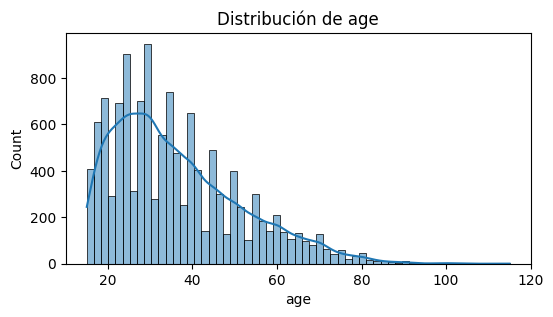

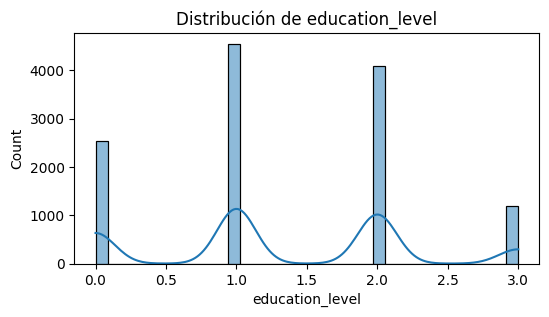

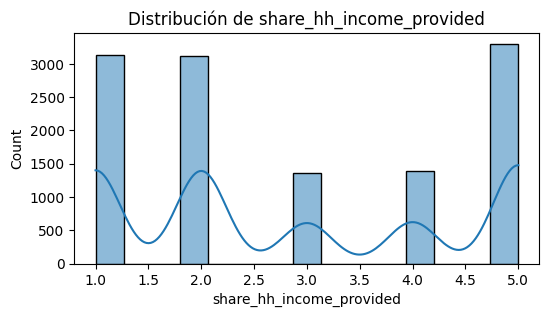

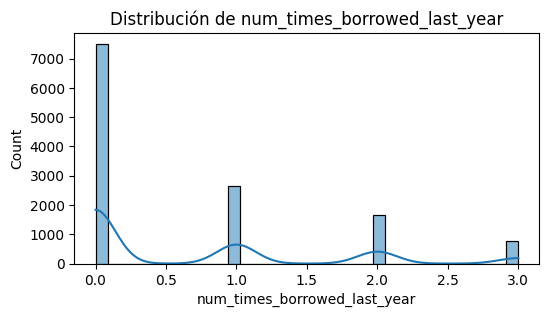

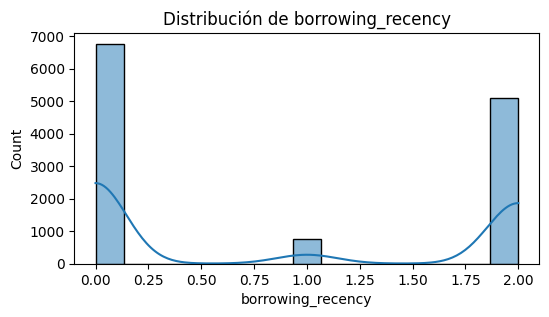

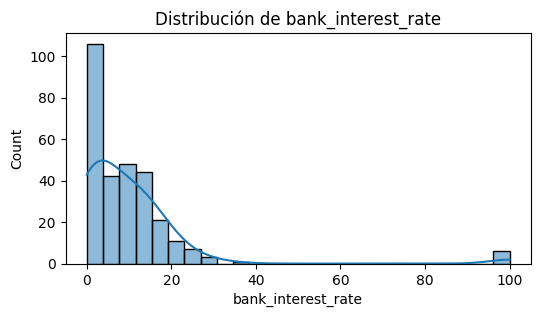

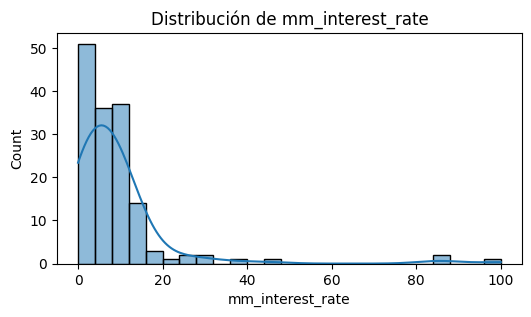

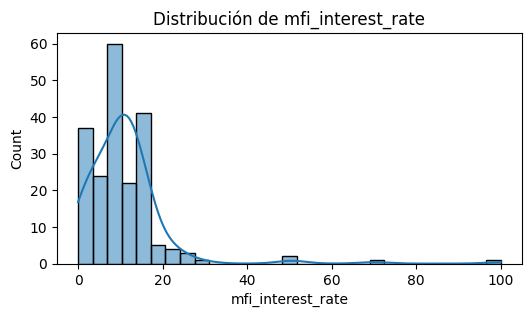

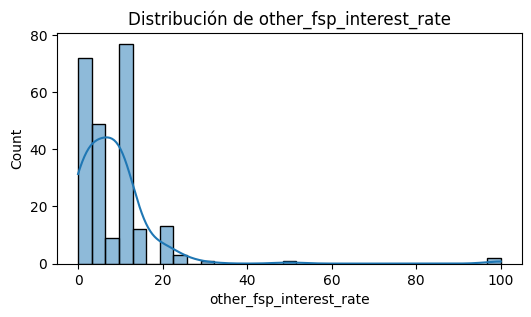

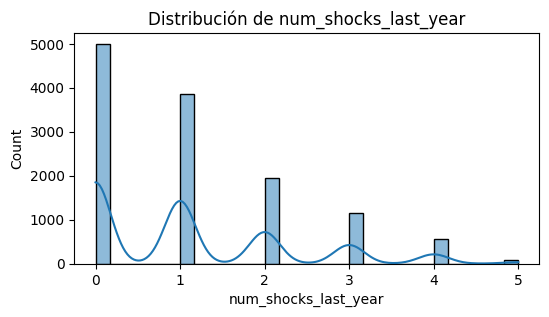

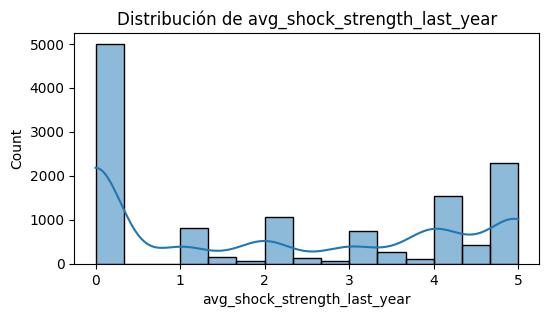

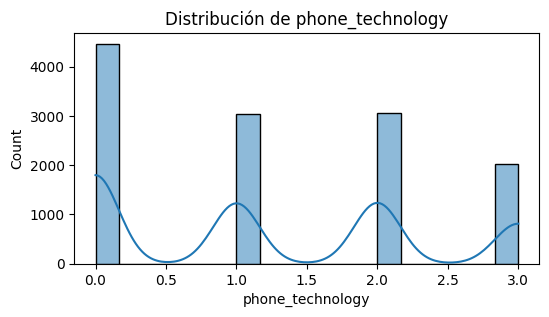

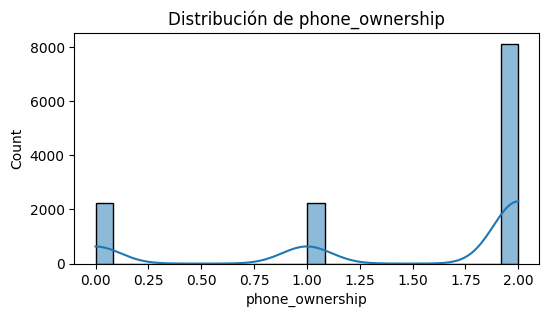

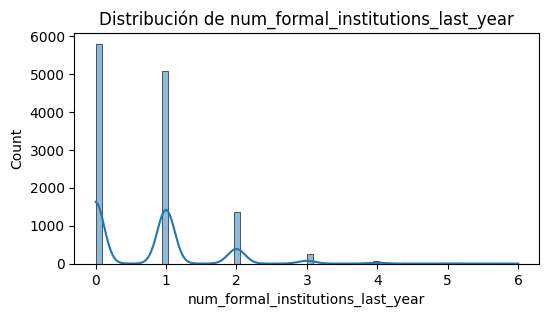

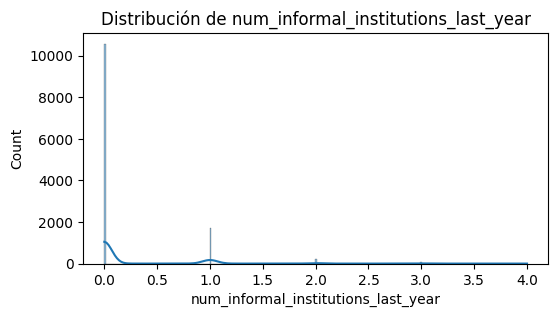

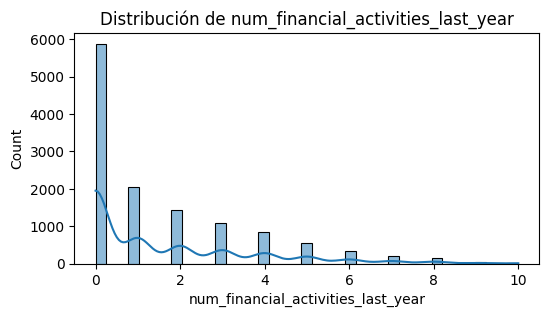

In [15]:
#distribucion de variables numericas 
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(X_train[col], kde=True)
    plt.title(f'Distribución de {col}')
    plt.show()

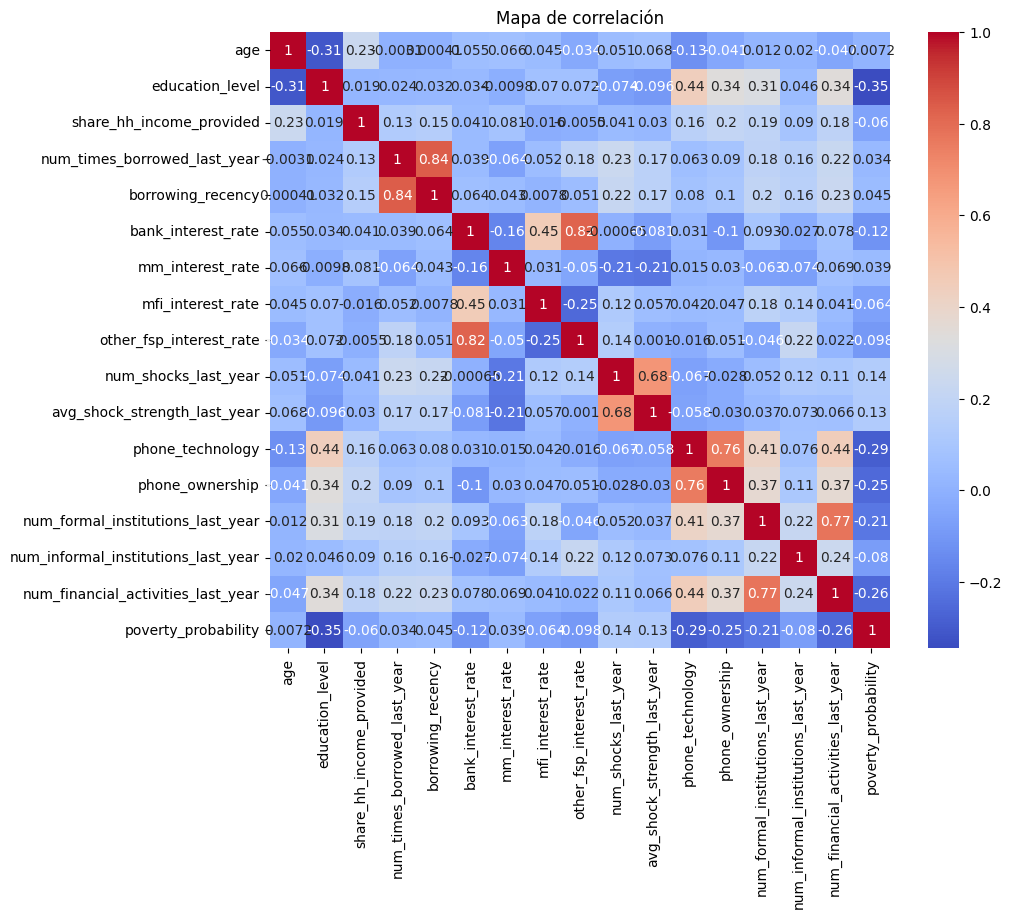

In [16]:
#correlacion con la variable objetivo
correlation = pd.concat([X_train[num_cols], y_train], axis=1).corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Mapa de correlación")
plt.show()

In [17]:
#cantidad de categorias por columna 
for col in cat_cols:
    print(f'{col}: {X_train[col].nunique()} categorías')

country: 7 categorías
religion: 5 categorías
relationship_to_hh_head: 7 categorías
employment_category_last_year: 5 categorías
employment_type_last_year: 5 categorías


In [18]:
#preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("bool", "passthrough", bool_cols)
    ]
)

In [21]:
#creación del pipeline
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("xgb", xgb_model)
])

In [22]:
#validacion interna
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
pipeline.fit(X_tr, y_tr)
y_val_pred = pipeline.predict(X_val)

In [23]:
#metricas sobre validación
mse = mean_squared_error(y_val, y_val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_val_pred)

print(f"RMSE (validación): {rmse:.4f}")
print(f"R2 Score (validación): {r2:.4f}")


RMSE (validación): 0.2159
R2 Score (validación): 0.4355


In [24]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
test_predictions = pipeline.predict(X_test)

In [26]:
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

In [27]:
pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", xgb)
])

In [28]:
param_grid = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

In [29]:
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=2
)


In [30]:
grid.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid.best_params_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Mejores hiperparámetros:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.01, 'model__max_depth': 7, 'model__n_estimators': 600, 'model__subsample': 0.8}


In [31]:
best_model = grid.best_estimator_

In [32]:
y_pred = best_model.predict(X_val)
rmse = mean_squared_error(y_val, y_pred)
print("MSE validación:", rmse)

MSE validación: 0.031432548457874715


In [33]:
mse = mean_squared_error(y_val, y_pred)  
rmse = np.sqrt(mse)     
print(rmse)

0.1772922684661537
